#Intro

Цел на проекта: Съзндаване на система за препоръки на текстови документи на потребители.


Outline: От самото начало си наумих, че ще използвам някакъв вид клъстеризация на теми за документите и ще прценям кой потребител кое би харесал (интерактналл).

Обработка на данни: За документите премахнах всички колони освен text,contentId, lang идеята бивайки че освен тема не искам да препоръчвам документ на език, който потребителя не знае. Поради прекалено малки бройки премахнах всички езици освен англлийски и португалски. Първоначално обмислях за всеки език да правя отелни клъстери, но прецених че поради това че два текста могат да имат една тема ,но да са на различен език и като изцяло малък обем на данни, че не искам да се усложняват нещата. Изполвах deep_translate  модула на google за превод да португалските текстове на английски.
За потребителните прецених че искам различни от примерните тежесни на 'intract'

След премахването на 'stopword' и TF-IDF започнах с клъстеризацията и това беше момента, в който разбрах че съм в беда. Няма ясна бройка клъстери и избрах 20 (на усет). След като избрах клъстерите идеята ми беше потребителите вместо да оценяват отделни документи да оценяват клъстери. Допълнителна сметка направих за това да видя ,кой потребител кои езици владее поставяйки всеки, който има повече от 5 точки ,като владеещ езика и позволява да бъде препоръчан доккумента.

Формулата за оценка е проста 'колко процента харесва клъстер' * 'разбира ли езика' (с 1 ако разбира езика , и 0.1 ако не го)

При първи тест резултата от попадени беше абсолютни 0% и след леко дебъгване и промяна на параметри стигнах до 0.58% , с което промених метриката да оценява дали точно сме уцелили клъстера с интереси на потребителя а не конктретна статия.

В ретрсопект трябваше да помисля как да оценя модела в самото начало , а не в последния момент след като всичко е готово. Имам усещането, че всъшност съм направил нещо наподобяващо Naive Bayes clasificator

#Imports

In [ ]:
!pip install deep_translator

In [24]:

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords
import scipy
import sklearn
from sklearn.metrics.pairwise import cosine_similarity
from deep_translator import GoogleTranslator
from tqdm import tqdm
import re
from sklearn.cluster import KMeans
import numpy as np

# Data

## Download

In [5]:
!gsutil cp -r gs://rec-sys-fmi/hw2-dataset .

Copying gs://rec-sys-fmi/hw2-dataset/shared_articles.csv...
Copying gs://rec-sys-fmi/hw2-dataset/users_interactions.csv...
- [2 files][ 28.6 MiB/ 28.6 MiB]                                                
Operation completed over 2 objects/28.6 MiB.                                     


In [ ]:
# !ls .
# !head hw2-dataset/shared_articles.csv
!head hw2-dataset/users_interactions.csv

timestamp,eventType,contentId,personId,sessionId,userAgent,userRegion,userCountry
1465413032,VIEW,-3499919498720038879,-8845298781299428018,1264196770339959068,,,
1465412560,VIEW,8890720798209849691,-1032019229384696495,3621737643587579081,"Mozilla/5.0 (Macintosh; Intel Mac OS X 10_11_2) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/52.0.2743.24 Safari/537.36",NY,US
1465416190,VIEW,310515487419366995,-1130272294246983140,2631864456530402479,,,
1465413895,FOLLOW,310515487419366995,344280948527967603,-3167637573980064150,,,
1465412290,VIEW,-7820640624231356730,-445337111692715325,5611481178424124714,,,
1465413742,VIEW,310515487419366995,-8763398617720485024,1395789369402380392,"Mozilla/5.0 (Windows NT 10.0; WOW64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/50.0.2661.102 Safari/537.36",MG,BR
1465415950,VIEW,-8864073373672512525,3609194402293569455,1143207167886864524,,,
1465415066,VIEW,-1492913151930215984,4254153380739593270,8743229464706506141,"Mozilla/5.0 (X11; Linux x86_64) AppleWe

## EDA

### Documents

In [ ]:
articles_df = pd.read_csv("hw2-dataset/shared_articles.csv")
articles_filtered = articles_df[articles_df['eventType'] == 'CONTENT SHARED'].copy()

languages_to_keep = ['en', 'pt']
articles_filtered = articles_filtered[articles_filtered['lang'].isin(languages_to_keep)]

cols_to_keep = ['contentId', 'text', 'lang']
articles_filtered = articles_filtered[cols_to_keep]

print(f"Dataset shape after filtering: {articles_filtered.shape}")
print("\nLanguage counts:")
print(articles_filtered['lang'].value_counts())

print("\nCleaned Data Sample:")
print(articles_filtered.head())



Dataset shape after filtering: (3040, 4)

Language counts:
lang
en    2211
pt     829
Name: count, dtype: int64

Cleaned Data Sample:
             contentId                                              title  \
1 -4110354420726924665  Ethereum, a Virtual Currency, Enables Transact...   
2 -7292285110016212249  Bitcoin Future: When GBPcoin of Branson Wins O...   
3 -6151852268067518688                       Google Data Center 360° Tour   
4  2448026894306402386  IBM Wants to "Evolve the Internet" With Blockc...   
5 -2826566343807132236  IEEE to Talk Blockchain at Cloud Computing Oxf...   

                                                text lang  
1  All of this work is still very early. The firs...   en  
2  The alarm clock wakes me at 8:00 with stream o...   en  
3  We're excited to share the Google Data Center ...   en  
4  The Aite Group projects the blockchain market ...   en  
5  One of the largest and oldest organizations fo...   en  


In [ ]:
# Translate portugese to english
en_df = articles_filtered[articles_filtered['lang'] == 'en'].copy()
pt_df = articles_filtered[articles_filtered['lang'] == 'pt'].copy()


translator = GoogleTranslator(source='pt', target='en')
print(f"Translating {len(pt_df)} Portuguese articles...")

translated_texts = []
count = 0

for text in pt_df['text']:
    try:
        # Truncate to 4500 chars to respect API limits
        clean_text = text[:4500] if isinstance(text, str) else ""
        translated_texts.append(translator.translate(clean_text))
    except:
        translated_texts.append("Translation Error")

    count += 1
    if count % 100 == 0:
        print(f"Progress: {count} articles translated...")

pt_df['text'] = translated_texts
articles_ready = pd.concat([en_df, pt_df], ignore_index=True)

articles_ready.to_csv("articles_translated.csv", index=False)
print("Done")

Translating 829 Portuguese articles...
Progress: 100 articles translated...
Progress: 200 articles translated...
Progress: 300 articles translated...
Progress: 400 articles translated...
Progress: 500 articles translated...
Progress: 600 articles translated...
Progress: 700 articles translated...
Progress: 800 articles translated...
Done


In [ ]:
error_count = (articles_ready['text'] == "Translation Error").sum()
print(f"Number of translation errors: {error_count}")

Number of translation errors: 0


In [7]:
articles_df = pd.read_csv("/content/articles_translated.csv")
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    cleaned_words = [w for w in words if w not in stop_words]

    return " ".join(cleaned_words)

articles_df['text_clean'] = articles_df['text'].apply(clean_text)
articles_df = articles_df[articles_df['text_clean'] != ""]
articles_df

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,contentId,title,text,lang,text_clean
0,-4110354420726924665,"Ethereum, a Virtual Currency, Enables Transact...",All of this work is still very early. The firs...,en,work still early first full public version eth...
1,-7292285110016212249,Bitcoin Future: When GBPcoin of Branson Wins O...,The alarm clock wakes me at 8:00 with stream o...,en,alarm clock wakes stream advertfree broadcasti...
2,-6151852268067518688,Google Data Center 360° Tour,We're excited to share the Google Data Center ...,en,excited share google data center tour youtube ...
3,2448026894306402386,"IBM Wants to ""Evolve the Internet"" With Blockc...",The Aite Group projects the blockchain market ...,en,aite group projects blockchain market could va...
4,-2826566343807132236,IEEE to Talk Blockchain at Cloud Computing Oxf...,One of the largest and oldest organizations fo...,en,one largest oldest organizations computing pro...
...,...,...,...,...,...
3035,-7264217791213422584,Qual é o valor da área de T&D na sua empresa?,It is essential that the companies' Human Reso...,pt,essential companies human resources department...
3036,-2402288292108892893,Como testar exceções em Java com o JUnit - Cod...,Introduction In this post I will show in a suc...,pt,introduction post show succinct practical way ...
3037,-624901815223005993,"A.I. Duet, crie melodias usando o aprendizado ...","Google has launched AI Duet, a new artificial ...",pt,google launched ai duet new artificial intelli...
3038,-8591127493017117985,"IBM e Visa transformam automóveis, eletrodomés...",IBM and Visa announced the industry's first co...,pt,ibm visa announced industrys first collaborati...


In [10]:
articles_df = articles_df.drop('title', axis=1)
articles_df = articles_df.drop('text', axis=1)
articles_df

,contentId,lang,text_clean
0,-4110354420726924665,en,work still early first full public version eth...
1,-7292285110016212249,en,alarm clock wakes stream advertfree broadcasti...
2,-6151852268067518688,en,excited share google data center tour youtube ...
3,2448026894306402386,en,aite group projects blockchain market could va...
4,-2826566343807132236,en,one largest oldest organizations computing pro...
...,...,...,...
3035,-7264217791213422584,pt,essential companies human resources department...
3036,-2402288292108892893,pt,introduction post show succinct practical way ...
3037,-624901815223005993,pt,google launched ai duet new artificial intelli...
3038,-8591127493017117985,pt,ibm visa announced industrys first collaborati...


### Interactions

In [11]:
interactions_df = pd.read_csv("hw2-dataset/users_interactions.csv")

valid_content_ids = articles_df['contentId'].unique()
interactions_filtered = interactions_df[interactions_df['contentId'].isin(valid_content_ids)].copy()

print(f"Interactions before sync: {len(interactions_df)}")
print(f"Interactions after sync: {len(interactions_filtered)}")

Interactions before sync: 72312
Interactions after sync: 72174


In [13]:
interactions_filtered = interactions_filtered.drop(['userAgent', 'userRegion','userCountry','sessionId'], axis=1)
interactions_filtered

,timestamp,eventType,contentId,personId
0,1465413032,VIEW,-3499919498720038879,-8845298781299428018
1,1465412560,VIEW,8890720798209849691,-1032019229384696495
2,1465416190,VIEW,310515487419366995,-1130272294246983140
3,1465413895,FOLLOW,310515487419366995,344280948527967603
4,1465412290,VIEW,-7820640624231356730,-445337111692715325
...,...,...,...,...
72307,1485190425,LIKE,-6590819806697898649,-9016528795238256703
72308,1485190425,VIEW,-5813211845057621660,102305705598210278
72309,1485190072,VIEW,-1999468346928419252,-9196668942822132778
72310,1485190434,VIEW,-6590819806697898649,-9016528795238256703


# Model

In [15]:
tfidf_vec = TfidfVectorizer(max_features=5000, max_df=0.95, min_df=5) #ingor words in more than 95% articles ,and in fewer than 5
tfidf_matrix = tfidf_vec.fit_transform(articles_df['text_clean'])

print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")

TF-IDF Matrix Shape: (3040, 5000)


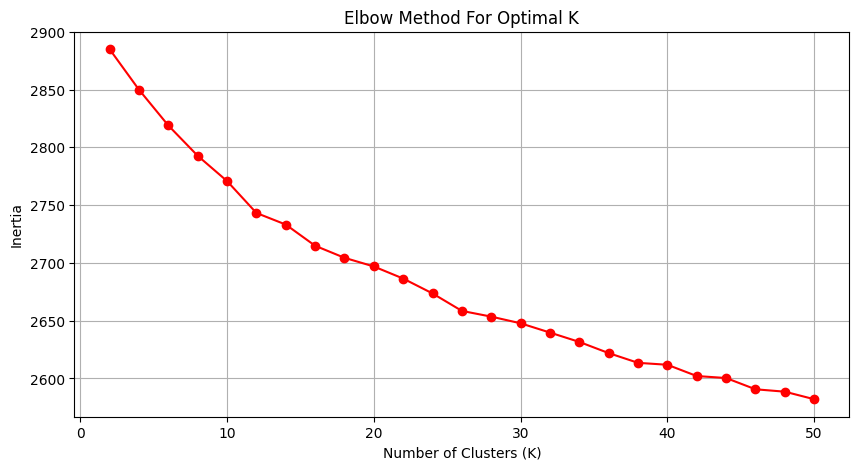

In [16]:
inertia = []
K_range = range(2, 51, 2)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(tfidf_matrix)
    inertia.append(model.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, 'ro-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal K')
plt.grid(True)
plt.show()

In [17]:
#Ужас, няма лакът! Хвърлям боб и избирам К=20.
optimal_k = 20
model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
articles_df['cluster'] = model.fit_predict(tfidf_matrix)

print("Top keywords per cluster:")
order_centroids = model.cluster_centers_.argsort()[:, ::-1]
terms = tfidf_vec.get_feature_names_out()

for i in range(optimal_k):
    top_10_words = [terms[ind] for ind in order_centroids[i, :10]]
    print(f"Cluster {i}: {', '.join(top_10_words)}")

Top keywords per cluster:
Cluster 0: game, pokmon, reality, mobile, augmented, hololens, players, virtual, world, go
Cluster 1: learning, machine, ai, intelligence, data, artificial, deep, neural, algorithms, tensorflow
Cluster 2: apple, apples, iphone, jobs, mac, ios, watch, siri, new, steve
Cluster 3: bank, banks, banking, financial, digital, fintech, customers, customer, account, services
Cluster 4: bot, bots, slack, chatbots, messenger, facebook, messaging, app, chat, apps
Cluster 5: see, specs, usa, credits, technical, storyline, trivia, taglines, written, quotes
Cluster 6: company, data, iot, new, technology, internet, one, said, app, also
Cluster 7: google, android, googles, apps, search, app, new, io, vr, also
Cluster 8: women, people, work, team, teams, business, paulo, th, development, one
Cluster 9: digital, data, business, companies, marketing, customer, customers, new, company, product
Cluster 10: docker, container, containers, run, image, command, kubernetes, jenkins, ima

In [18]:
articles_df

,contentId,lang,text_clean,cluster
0,-4110354420726924665,en,work still early first full public version eth...,12
1,-7292285110016212249,en,alarm clock wakes stream advertfree broadcasti...,6
2,-6151852268067518688,en,excited share google data center tour youtube ...,7
3,2448026894306402386,en,aite group projects blockchain market could va...,12
4,-2826566343807132236,en,one largest oldest organizations computing pro...,12
...,...,...,...,...
3035,-7264217791213422584,pt,essential companies human resources department...,8
3036,-2402288292108892893,pt,introduction post show succinct practical way ...,19
3037,-624901815223005993,pt,google launched ai duet new artificial intelli...,7
3038,-8591127493017117985,pt,ibm visa announced industrys first collaborati...,18


In [19]:
id_to_cluster = dict(zip(articles_df['contentId'], articles_df['cluster']))

interactions_df['cluster'] = interactions_df['contentId'].map(id_to_cluster)

interactions_df = interactions_df.dropna(subset=['cluster'])
interactions_df['cluster'] = interactions_df['cluster'].astype(int)

print("Updated Interactions Table:")
print(interactions_df[['personId', 'cluster', 'eventType']].head())

print(f"\nRemaining interaction events: {len(interactions_df)}")

Updated Interactions Table:
              personId  cluster eventType
0 -8845298781299428018       14      VIEW
1 -1032019229384696495       11      VIEW
2 -1130272294246983140        8      VIEW
3   344280948527967603        8    FOLLOW
4  -445337111692715325       14      VIEW

Remaining interaction events: 72174


In [20]:
weights = {'VIEW': 1, 'LIKE': 3, 'BOOKMARK': 5, 'FOLLOW': 10, 'COMMENT CREATED': 5}
interactions_df['weight'] = interactions_df['eventType'].map(weights)

user_topic_strength = interactions_df.groupby(['personId', 'cluster'])['weight'].sum().reset_index()

print("User-Topic Strength Sample:")
print(user_topic_strength.head())

User-Topic Strength Sample:
              personId  cluster  weight
0 -9223121837663643404        0       3
1 -9223121837663643404        2       3
2 -9223121837663643404        3       2
3 -9223121837663643404        4       2
4 -9223121837663643404        6       6


In [49]:
id_to_lang = dict(zip(articles_df['contentId'], articles_df['lang']))
interactions_df['lang'] = interactions_df['contentId'].map(id_to_lang)

user_lang_strength = interactions_df.groupby(['personId', 'lang'])['weight'].sum().unstack(fill_value=0)

langBarier = 5 # Barier of wich we will determine if user knows the language
user_lang_strength['prefers_en'] = user_lang_strength['en'] >= langBarier
user_lang_strength['prefers_pt'] = user_lang_strength['pt'] >= langBarier

print("Language Preference Sample:")
print(user_lang_strength.head())

Language Preference Sample:
lang                  en  pt  prefers_en  prefers_pt
personId                                            
-9223121837663643404  39  26        True        True
-9212075797126931087   9   2        True       False
-9207251133131336884  10  10        True        True
-9199575329909162940  12   5        True        True
-9196668942822132778   1   9       False        True


In [51]:
train_interactions, test_interactions = train_test_split(interactions_df,
                                                         test_size=0.10)

In [52]:
user_profiles = train_interactions.pivot_table(index='personId',
                                               columns='cluster',
                                               values='weight',
                                               aggfunc='sum').fillna(0)

user_profiles = user_profiles.div(user_profiles.sum(axis=1), axis=0)
print(user_profiles.head())

cluster                     0    1         2         3         4    5   \
personId                                                                 
-9223121837663643404  0.051724  0.0  0.034483  0.034483  0.017241  0.0   
-9212075797126931087  0.000000  0.0  0.000000  0.000000  0.000000  0.0   
-9207251133131336884  0.000000  0.0  0.000000  0.000000  0.000000  0.0   
-9199575329909162940  0.071429  0.0  0.000000  0.000000  0.000000  0.0   
-9196668942822132778  0.000000  0.0  0.000000  0.100000  0.000000  0.0   

cluster                     6         7         8         9    10   11   12  \
personId                                                                      
-9223121837663643404  0.103448  0.086207  0.000000  0.051724  0.0  0.0  0.0   
-9212075797126931087  0.000000  0.000000  0.090909  0.000000  0.0  0.0  0.0   
-9207251133131336884  0.000000  0.000000  0.000000  0.000000  0.0  0.0  0.0   
-9199575329909162940  0.285714  0.000000  0.000000  0.571429  0.0  0.0  0.0   
-919666

In [53]:
def recommend_for_user(person_id, top_n=10):
    if person_id not in user_profiles.index:
        return pd.DataFrame()

    user_prob_vector = user_profiles.loc[person_id]


    has_en = user_lang_strength.loc[person_id]['prefers_en'] if person_id in user_lang_strength.index else False
    has_pt = user_lang_strength.loc[person_id]['prefers_pt'] if person_id in user_lang_strength.index else False

    rec_df = articles_df.copy()

    rec_df['topic_score'] = rec_df['cluster'].map(user_prob_vector).fillna(0)

    def calculate_lang_weight(row):
        if row['lang'] == 'en' and has_en: return 1.0
        if row['lang'] == 'pt' and has_pt: return 1.0
        return 0.1 # The "Penalty" for unknown languages

    rec_df['lang_weight'] = rec_df.apply(calculate_lang_weight, axis=1)

    rec_df['final_score'] = rec_df['topic_score'] * rec_df['lang_weight']

    seen_ids = train_interactions[train_interactions['personId'] == person_id]['contentId'].unique()
    rec_df = rec_df[~rec_df['contentId'].isin(seen_ids)]

    return rec_df.sort_values('final_score', ascending=False).head(top_n)

In [55]:
test_user_id = user_profiles.index[0]
recommendations = recommend_for_user(test_user_id)

print(f"Top 10 Recommendations for User {test_user_id}:")
print(recommendations[ ['lang', 'cluster', 'final_score']])

Top 10 Recommendations for User -9223121837663643404:
     lang  cluster  final_score
1384   en       16     0.155172
1385   en       16     0.155172
9      en       16     0.155172
1386   en       16     0.155172
1387   en       16     0.155172
2999   pt       16     0.155172
2203   en       16     0.155172
667    en       16     0.155172
676    en       16     0.155172
2172   en       16     0.155172


In [57]:
def evaluate_model(test_set, top_n=10):
    hits = 0
    total_evaluable_users = 0

    common_users = set(test_set['personId']).intersection(set(user_profiles.index))

    print(f"Evaluating {len(common_users)} users...")

    for person_id in common_users:
        # 1. What did the user actually click in the test set?
        actual_test_clusters = set(test_set[test_set['personId'] == person_id]['cluster'])

        # 2. What does our model recommend?
        recs = recommend_for_user(person_id, top_n=top_n)

        if not recs.empty:
            recommended_clusters = set(recs['cluster'])

            if len(actual_test_clusters.intersection(recommended_clusters)) > 0:
                hits += 1

            total_evaluable_users += 1

    recall_score = (hits / total_evaluable_users) * 100 if total_evaluable_users > 0 else 0
    return recall_score

# Execute evaluation
final_score = evaluate_model(test_interactions, top_n=5) # 5 наместо  10 за по добра точност :)

print("-" * 30)
print(f"FINAL EVALUATION RESULT")
print(f"Cluster-Hit Recall@10: {final_score:.2f}%")
print("-" * 30)

Evaluating 1121 users...
------------------------------
FINAL EVALUATION RESULT
Cluster-Hit Recall@10: 62.36%
------------------------------
